## MLP Sentiment Analysis IMDB

In [6]:
!pip -q install nltk textblob gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_path = "/content/drive/MyDrive/IMDB_Project"
os.makedirs(project_path, exist_ok=True)

Mounted at /content/drive


Import Deep Learning Libraries

In [10]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import gensim.downloader as api

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

Load the IMDB Dataset

In [8]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [9]:
df = pd.read_csv(path+"/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Clean the Data

In [13]:
def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'<.*?>', '', text) # Remove HTML Tags
    text = " ".join(text.split()) # Remove extra spaces
    return text

print("Cleaning text...")
df["review_clean"] = df["review"].astype(str).apply(clean_text)
print("Text cleaning complete!")

# Convert 'positive'/'negative' strings to 1s and 0s
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})

# Now grab the values!
y = df["label"].values

Cleaning text...
Text cleaning complete!


Tokenization and Padding

In [14]:
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 200

print("Tokenizing text...")
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["review_clean"])
word_index = tokenizer.word_index

# Convert text to sequences and pad them
sequences = tokenizer.texts_to_sequences(df["review_clean"])
X_seq = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
y = df["label"].values

print(f"Shape of data tensor (X): {X_seq.shape}")

# Train / Validation / Test Split (60% / 20% / 20%)
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Tokenizing text...
Shape of data tensor (X): (50000, 200)
Training set: 30000 samples
Validation set: 10000 samples
Testing set: 10000 samples


Load Pretrained Word2Vec

In [15]:
print("Downloading Word2Vec model... (This takes a minute)")
word2vec = api.load('word2vec-google-news-300')

EMBEDDING_DIM = 300
num_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

hit, miss = 0, 0
for word, i in word_index.items():
    if i >= MAX_VOCAB_SIZE:
        continue
    try:
        embedding_matrix[i] = word2vec[word]
        hit += 1
    except KeyError:
        miss += 1

print(f"Word2Vec loaded! {hit} words mapped successfully ({miss} missed).")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded! 17420 words mapped successfully (2579 missed).


Build & Train Model 1 (Bidirectional LSTM)

In [16]:
# Build the LSTM
model_lstm = Sequential([
    Embedding(input_dim=num_words, output_dim=EMBEDDING_DIM, weights=[embedding_matrix],
              input_length=MAX_SEQUENCE_LENGTH, trainable=False),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile with Adam
model_lstm.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Train with Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting training...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Starting training...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.7074 - loss: 0.5775 - val_accuracy: 0.7862 - val_loss: 0.5038
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.8043 - loss: 0.4552 - val_accuracy: 0.8259 - val_loss: 0.3982
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.7559 - loss: 0.5058 - val_accuracy: 0.7806 - val_loss: 0.4724
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.8330 - loss: 0.3988 - val_accuracy: 0.8414 - val_loss: 0.3604
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 232s 988ms/step - accuracy: 0.8395 - loss: 0.3740 - val_accuracy: 0.8398 - val_loss: 0.3631
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.8372 - loss: 0.3896 - val_accuracy: 0.8328 - val_loss: 0.3866
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.8553 - loss: 0.3484 - val_accuracy: 0.8604 - val_loss: 0.3266
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 246s 972ms/step - accuracy: 0.864

Evaluate the Bidirectional LSTM & Save Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.8781 - loss: 0.3067

--- Bidirectional LSTM Test Accuracy: 0.8781 ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 149ms/step


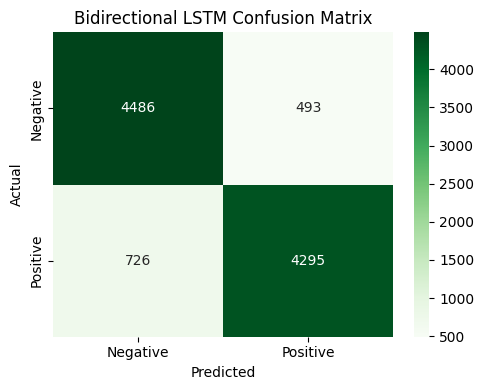

LSTM results saved successfully!


In [22]:
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test)
print(f"\n--- Bidirectional LSTM Test Accuracy: {test_acc_lstm:.4f} ---")

# Get predictions
predictions_probs_lstm = model_lstm.predict(X_test)
lstm_predictions = (predictions_probs_lstm >= 0.5).astype(int)

# Plot Confusion Matrix
cm_lstm = confusion_matrix(y_test, lstm_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bidirectional LSTM Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{project_path}/lstm_confusion_matrix.png")
plt.show()

# Save results
lstm_results = pd.DataFrame({
    "id": range(len(lstm_predictions)),
    "label": lstm_predictions.flatten()
})
lstm_results.to_csv(f"{project_path}/lstm_submission.csv", index=False)
print("LSTM results saved successfully!")

Build & Train Model 2 (1D CNN)

In [20]:
# Build the 1D CNN Architecture
model_cnn = Sequential([
    # 1. Shared Embedding Layer (reusing the Word2Vec matrix)
    Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False
    ),

    # 2. Convolutional Layer
    Conv1D(filters=128, kernel_size=5, activation='relu'),

    # 3. Pooling Layer (grabs the most important features)
    GlobalMaxPooling1D(),

    # 4. Dense Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.5), # Regularization

    # 5. Output Layer
    Dense(1, activation='sigmoid')
])

# Compile with Adam
model_cnn.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

print("Starting training for 1D CNN...")
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop] # Reusing the early stopping from before!
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Starting training for 1D CNN...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 139s 567ms/step - accuracy: 0.7659 - loss: 0.4825 - val_accuracy: 0.8394 - val_loss: 0.3624
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 135s 574ms/step - accuracy: 0.8665 - loss: 0.3279 - val_accuracy: 0.8664 - val_loss: 0.3096
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 130s 552ms/step - accuracy: 0.8996 - loss: 0.2612 - val_accuracy: 0.8719 - val_loss: 0.3012
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 147s 574ms/step - accuracy: 0.9262 - loss: 0.2011 - val_accuracy: 0.8639 - val_loss: 0.3272
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 549ms/step - accuracy: 0.9537 - loss: 0.1413 - val_accuracy: 0.8689 - val_loss: 0.3275
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 557ms/step - accuracy: 0.9746 - loss: 0.0893 - val_accuracy: 0.8724 - val_loss: 0.3636


Evaluate the 1D CNN & Save Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8758 - loss: 0.2944

--- 1D CNN Test Accuracy: 0.8758 ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step


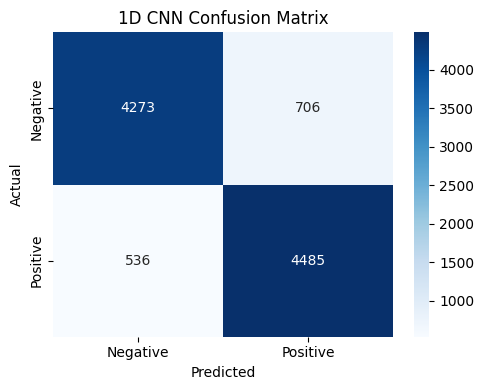

In [21]:
# Evaluate the model on the unseen test set
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test)
print(f"\n--- 1D CNN Test Accuracy: {test_acc_cnn:.4f} ---")

# Get predictions
predictions_probs_cnn = model_cnn.predict(X_test)
cnn_predictions = (predictions_probs_cnn >= 0.5).astype(int)

# Plot Confusion Matrix
cm_cnn = confusion_matrix(y_test, cnn_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("1D CNN Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{project_path}/cnn_confusion_matrix.png")
plt.show()

# Save results
cnn_results = pd.DataFrame({
    "id": range(len(cnn_predictions)),
    "label": cnn_predictions.flatten()
})
cnn_results.to_csv(f"{project_path}/cnn_submission.csv", index=False)